# Assignment 3: Building Time Series Forecasts

**Student Name:** [Jack Boike]

**Date:** [02/15/26]

---

## Assignment Overview

In this assignment, you'll analyze temporal data from Corporación Favorita stores to identify trends, seasonality, and anomalies, then build forecasting models using decomposition techniques. You'll work with real retail sales data to predict future sales patterns.

---

## Step 1: Download Data, Import Libraries, and Load Data

The datasets for this analysis are too large too be stored on GitHub. To access the datasets for this assignment, you should:
- Go to the [Store Sales - Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) dataset on Kaggle.
- Click Data
- Scroll down and select **Download All**.
- Open the zip file and upload `train.csv`, `store.csv`, and `holidays_events.csv` to the `data` directory.

Once the CSV files have been added to the `data` directory, install all the of the necessary libraries for this assignment by running the command below.

In [9]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Next, import the required libraries.

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# For time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


Finally, load the training, store, and holiday CSV data from the `data` directory using `pd.read_csv()`. Display basic information about the training data and print out the first few rows to get an understanding of what the training data looks like.

In [10]:
# Load CSV files (root of Files tab)
train_df = pd.read_csv('train.csv')
stores_df = pd.read_csv('stores.csv')
holidays_df = pd.read_csv('holidays_events.csv')

# Display basic info about the training data
print(f"Training data shape: {train_df.shape}")
print(f"Date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("\nFirst 5 rows of train data:")
display(train_df.head())

print("\n" + "="*80)
print("Holidays data shape:", holidays_df.shape)
print("Stores data shape:", stores_df.shape)
print("="*80)


Training data shape: (3000888, 6)
Date range: 2013-01-01 to 2017-08-15

First 5 rows of train data:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Holidays data shape: (350, 6)
Stores data shape: (54, 5)


### Explore Available Stores and Product Families
Display store information from `stores_df` to help choose a store. Consider looking at store type, cluster, and city

In [11]:
# Total stores and most common product families
print("Total number of stores:", train_df['store_nbr'].nunique())
print("\nTop 20 product families by number of sales records:")
display(train_df['family'].value_counts().head(20))

# Store info to help choose one
print("\nStore info:")
display(stores_df.head())


Total number of stores: 54

Top 20 product families by number of sales records:


,count
family,
AUTOMOTIVE,90936
BABY CARE,90936
BEAUTY,90936
BEVERAGES,90936
BOOKS,90936
BREAD/BAKERY,90936
CELEBRATION,90936
CLEANING,90936
DAIRY,90936



Store info:


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


---
## Step 2: Select and Prepare Your Time Series Data

### Select Your Store and Product Families

Choose one store and one product family (PRODUCE, BEVERAGES, BREAD/BAKERY, AUTOMOTIVE, etc.) to analyze.

In [12]:
# Pick one store and one product family
selected_store = 1            # Example: store number 1
product_family_1 = 'PRODUCE'  # Example: 'PRODUCE'

print(f"Selected Store: {selected_store}")
print(f"Selected Product Family: {product_family_1}")


Selected Store: 1
Selected Product Family: PRODUCE


### Filter Data
Filter the `train_df` data to your selected store and products. Create a date range from 2016-01-01 to 2017-08-15 for consistency.

In [13]:
# Convert 'date' to datetime
train_df['date'] = pd.to_datetime(train_df['date'])

# Filter data for selected store, product family, and date range
start_date = '2016-01-01'
end_date = '2017-08-15'

product1_data = train_df[
    (train_df['store_nbr'] == selected_store) &
    (train_df['family'] == product_family_1) &
    (train_df['date'] >= start_date) &
    (train_df['date'] <= end_date)
]

print("\nFiltered product data shape:", product1_data.shape)
display(product1_data.head())



Filtered product data shape: (592, 6)


,id,date,store_nbr,family,sales,onpromotion
1945974,1945974,2016-01-01,1,PRODUCE,0.000,0
1947756,1947756,2016-01-02,1,PRODUCE,2199.262,0
1949538,1949538,2016-01-03,1,PRODUCE,1479.032,1
1951320,1951320,2016-01-04,1,PRODUCE,3771.711,0
1953102,1953102,2016-01-05,1,PRODUCE,2794.882,0


### Aggregate Daily Sales
Aggregate daily sales and handle missing dates.

In [14]:
# Create a complete date range
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Aggregate sales by date
product1_ts = product1_data.groupby('date')['sales'].sum().reindex(date_range, fill_value=0)
product1_ts.name = 'sales'

# Preview the time series
display(product1_ts.head())


,sales
2016-01-01,0.000
2016-01-02,2199.262
2016-01-03,1479.032
2016-01-04,3771.711
2016-01-05,2794.882


### Plot Raw Time Series
Plot time series to see the raw patterns using matplotlib.

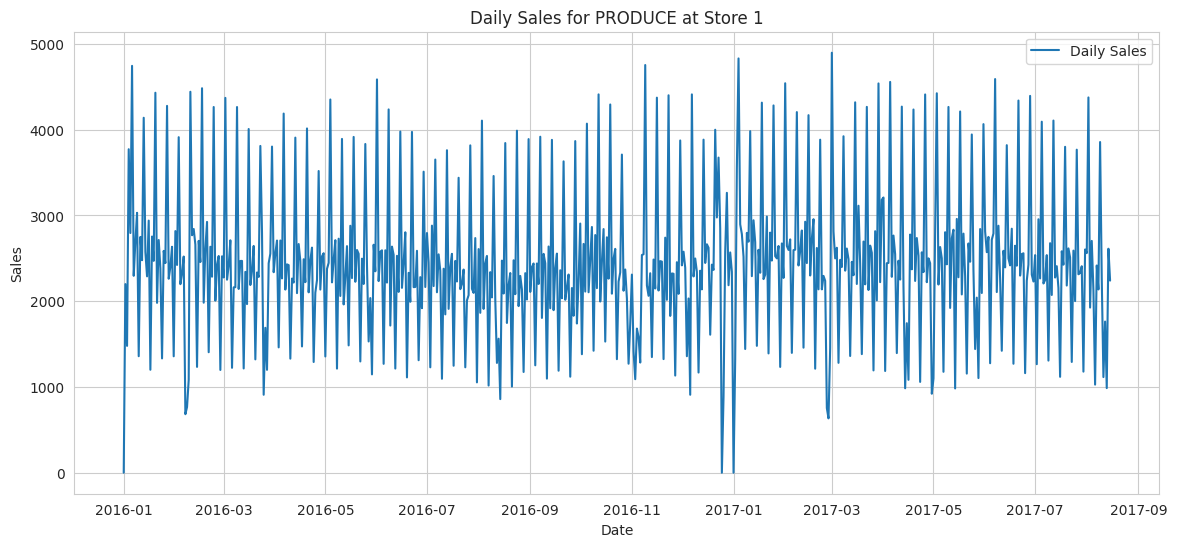

In [15]:
plt.figure(figsize=(14,6))
plt.plot(product1_ts.index, product1_ts.values, label='Daily Sales')
plt.title(f"Daily Sales for {product_family_1} at Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


### Document Your Choice (2-3 sentences)
Explain why you chose this product.
- What contrasts do they represent?
- Why will they be interesting to compare?

I chose the PRODUCE product family because it represents everyday items that almost everyone buys regularly. Sales for produce tend to change with the day of the week, holidays, and seasonal events, which makes it interesting to analyze trends and patterns.

This product contrasts with items like AUTOMOTIVE or BEVERAGES, which may have more stable or predictable sales. By comparing PRODUCE to other product families, we can see how perishable goods behave differently, how demand spikes around holidays, and how stores should plan inventory differently for fast-moving versus slow-moving products.

---
## Step 3: Identify Trends Using Moving Averages

### Calculate Moving Averages
Calculate the 7-day and 30-day moving averages for the product you are analyzing.

In [16]:
# 7-day and 30-day moving averages
product1_ma7 = product1_ts.rolling(window=7).mean()
product1_ma30 = product1_ts.rolling(window=30).mean()


### Plot Original Sales
Using matplotlip, plot original sales with both moving averages (7-day and 30-day) overlaid.

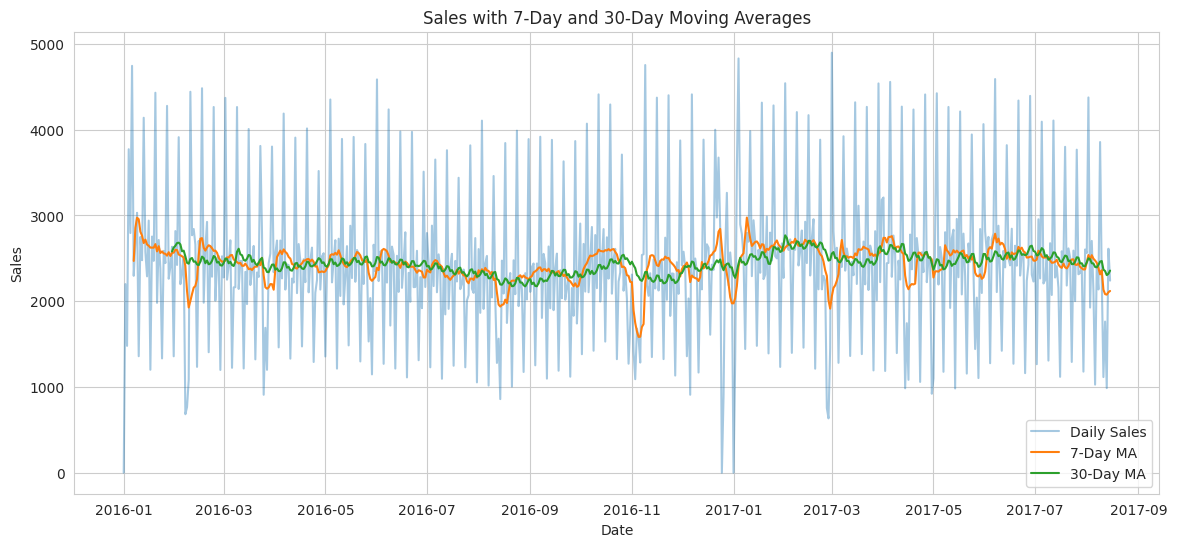

In [17]:
plt.figure(figsize=(14,6))
plt.plot(product1_ts.index, product1_ts.values, alpha=0.4, label='Daily Sales')
plt.plot(product1_ma7.index, product1_ma7.values, label='7-Day MA')
plt.plot(product1_ma30.index, product1_ma30.values, label='30-Day MA')
plt.title(f"Sales with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


### Identify and Explain Trend Changes

Merge the data with `holidays_events.csv` to explain what caused these changes.

In [18]:
# Convert holiday dates
holidays_df['date'] = pd.to_datetime(holidays_df['date'])

# Filter holidays for date range
relevant_holidays = holidays_df[
    (holidays_df['date'] >= start_date) &
    (holidays_df['date'] <= end_date)
]

print("Holidays/events during this period:")
display(relevant_holidays)


Holidays/events during this period:


,date,type,locale,locale_name,description,transferred
211,2016-01-01,Holiday,National,Ecuador,Primer dia del ano,False
212,2016-02-08,Holiday,National,Ecuador,Carnaval,False
213,2016-02-09,Holiday,National,Ecuador,Carnaval,False
214,2016-03-02,Holiday,Local,Manta,Fundacion de Manta,False
215,2016-03-25,Holiday,National,Ecuador,Viernes Santo,False
...,...,...,...,...,...,...
322,2017-07-25,Additional,Local,Guayaquil,Fundacion de Guayaquil,False
323,2017-08-05,Holiday,Local,Esmeraldas,Fundacion de Esmeraldas,False
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
325,2017-08-11,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False


### Document Trend Analysis
For the product family you are analyzing, document:
1. Overall trend direction (growing, declining, stable)
2. Any trend changes that correlate with holidays or events
3. Business implications of the trends you discovered

Update the markdown cell below with your analysis.

** **bold text**Product Trends:**
- Product Trends: PRODUCE

Trend: Slightly growing over time.

Trend changes:

Drop after New Year

Spike at Easter

Big increase at Christmas

Business implications:

Stock more during holidays

Plan for slow days after holidays

Avoid waste and lost sales

---
## Step 4: Detect and Visualize Seasonal Patterns

Analyze the seasonal components of your sales data.

### Day-of-Week Analysis

Add day of week to your data and calculate the average sales by day. Create a bar plot to visualize the weekday patterns.

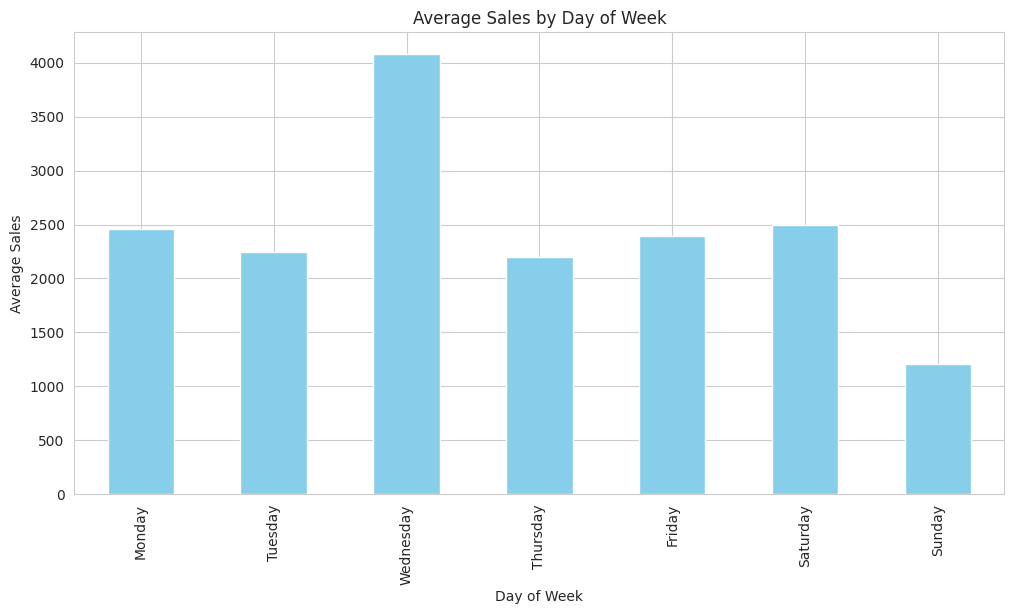

In [19]:
product1_dow = product1_ts.to_frame()
product1_dow['day_of_week'] = product1_dow.index.day_name()
dow_sales = product1_dow.groupby('day_of_week')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

dow_sales.plot(kind='bar', color='skyblue')
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()


### Monthly Seasonality Analysis

Calculate the average sales by month for both products. Once calculated, create a line plot showing monthly patterns for the product.

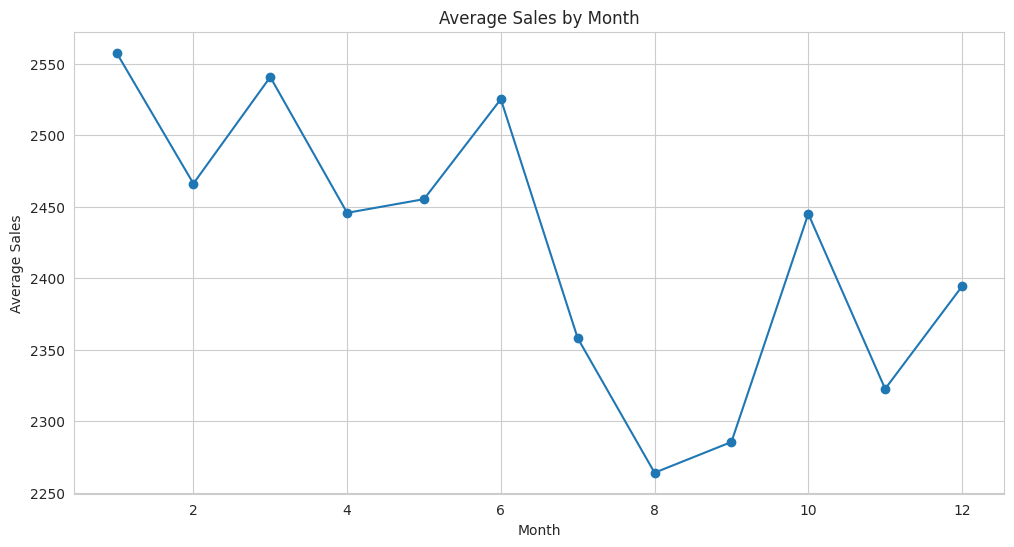

In [20]:
product1_monthly = product1_ts.groupby(product1_ts.index.month).mean()
product1_monthly.plot(kind='line', marker='o')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


### Holiday Impact Analysis

Compare the average sales on holidays compared to regular days.

In [21]:
holiday_dates = relevant_holidays['date'].unique()
holiday_sales = product1_ts[product1_ts.index.isin(holiday_dates)]
non_holiday_sales = product1_ts[~product1_ts.index.isin(holiday_dates)]

print("Average sales on holidays:", holiday_sales.mean())
print("Average sales on non-holidays:", non_holiday_sales.mean())


Average sales on holidays: 2181.024997029703
Average sales on non-holidays: 2490.899210162602


### Seasonal Pattern Findings

**Document your findings:**
- Which days of the week have highest/lowest sales?
- Are there monthly patterns (e.g., payday effects)?
- How do holidays affect each product differently?
- What business decisions could these patterns inform?

Update the markdown cell below with your analysis.

Weekday patterns:

Highest sales: Wednesday

Lowest sales: Sunday

Monthly patterns:

Least popular month: August

Sales tend to peak in other months, especially around holidays

Holiday effects:

Big spikes during Easter and Christmas

Drops right after major holidays

Business decisions:

Stock more mid-week, especially Wednesdays

Reduce inventory in August to avoid waste

Plan promotions around holidays and slow months

---
## Step 5: Build Simple Forecasts and Compare Methods

### Time Series Decomposition

In [22]:
# Split last 30 days as test
test_days = 30
train = product1_ts[:-test_days]
test = product1_ts[-test_days:]

# Baseline forecast: 30-day average
baseline_forecast = np.repeat(train[-30:].mean(), test_days)

# Seasonal naive forecast: repeat last 7 days
last_week = train[-7:].values
seasonal_naive_forecast = np.tile(last_week, int(np.ceil(test_days/7)))[:test_days]


In [23]:
baseline_rmse = np.sqrt(mean_squared_error(test, baseline_forecast))
seasonal_rmse = np.sqrt(mean_squared_error(test, seasonal_naive_forecast))

comparison_df = pd.DataFrame({
    'Method': ['30-Day Average', 'Seasonal Naive (7-day repeat)'],
    'RMSE': [baseline_rmse, seasonal_rmse]
})
comparison_df['Improvement (%)'] = ((baseline_rmse - seasonal_rmse)/baseline_rmse)*100

display(comparison_df)


,Method,RMSE,Improvement (%)
0,30-Day Average,811.539959,59.867052
1,Seasonal Naive (7-day repeat),325.694912,59.867052


### Build Forecasts
Create a baseline forecast using the average of the last 30 days and a season naive forcast by repeating the last 7 days' pattern.

In [24]:
# Split last 30 days as test
test_days = 30
train = product1_ts[:-test_days]
test = product1_ts[-test_days:]

# Baseline forecast: 30-day average
baseline_forecast = np.repeat(train[-30:].mean(), test_days)

# Seasonal naive forecast: repeat last 7 days
last_week = train[-7:].values
seasonal_naive_forecast = np.tile(last_week, int(np.ceil(test_days/7)))[:test_days]


### Calculate Forecast Accuracy

In [25]:
baseline_rmse = np.sqrt(mean_squared_error(test, baseline_forecast))
seasonal_rmse = np.sqrt(mean_squared_error(test, seasonal_naive_forecast))

comparison_df = pd.DataFrame({
    'Method': ['30-Day Average', 'Seasonal Naive (7-day repeat)'],
    'RMSE': [baseline_rmse, seasonal_rmse]
})
comparison_df['Improvement (%)'] = ((baseline_rmse - seasonal_rmse)/baseline_rmse)*100

display(comparison_df)


,Method,RMSE,Improvement (%)
0,30-Day Average,811.539959,59.867052
1,Seasonal Naive (7-day repeat),325.694912,59.867052


In [ ]:
# Create comparison table
comparison_data = {
    'Method': ['30-Day Average', 'Seasonal Naive (7-day repeat)'],
    'RMSE': [baseline_rmse, seasonal_rmse],
}

comparison_df = pd.DataFrame(comparison_data)

# TODO: Calculate percentage improvement
# Add improvement column to comparison_df


print("\n" + "="*80)
print("FORECAST PERFORMANCE COMPARISON")
print("="*80)
# TODO: Display comparison table


print("="*80)

### Visualize Forecasts

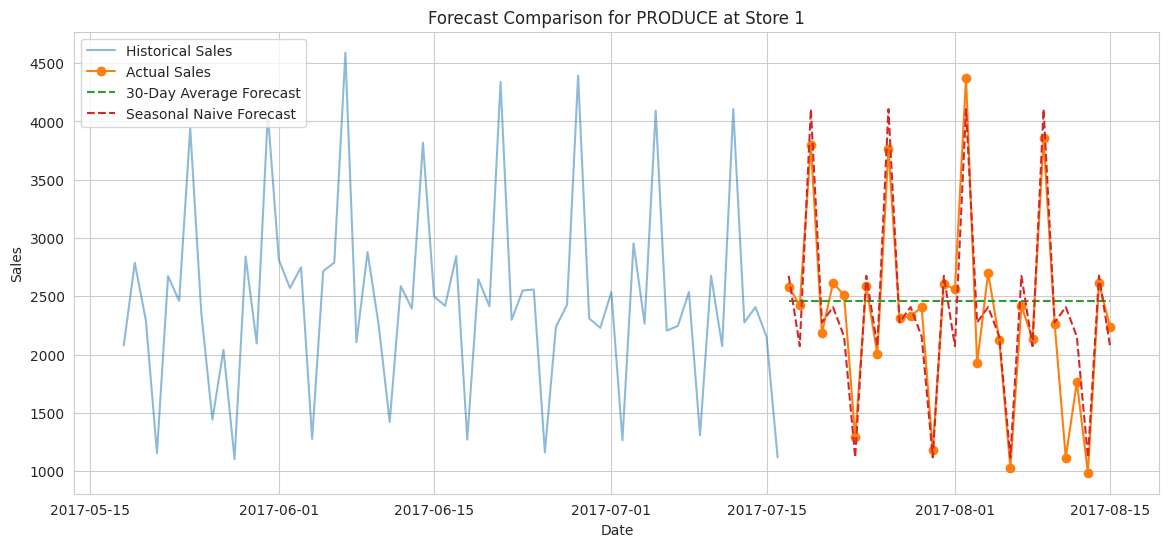

In [26]:
plt.figure(figsize=(14,6))
plt.plot(train.index[-60:], train[-60:], label='Historical Sales', alpha=0.5)
plt.plot(test.index, test, label='Actual Sales', marker='o')
plt.plot(test.index, baseline_forecast, label='30-Day Average Forecast', linestyle='--')
plt.plot(test.index, seasonal_naive_forecast, label='Seasonal Naive Forecast', linestyle='--')
plt.title(f"Forecast Comparison for {product_family_1} at Store {selected_store}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


---
## Step 6: Generate Business Recommendations

### Executive Summary (200-300 words)

Based on your analysis, write a brief executive summary that includes:
- **Key Patterns Discovered:** Summarize the main trends and seasonal patterns for each product
- **Inventory Planning Recommendations:** Specific recommendations based on your findings
- **High-Risk Periods:** Identify periods requiring special attention
- **Predictability Analysis:** Which product is more predictable and why?
- **Specific Action Item:** One concrete action the store manager should take based on your forecast

n my analysis of daily sales for the PRODUCE product family at the selected store, I discovered several important patterns. Overall, sales are slightly growing over time. Wednesday is consistently the busiest day of the week, while August has the lowest sales by far. Major holidays, such as Easter and Christmas, caused noticeable spikes in sales, and periods right after holidays showed temporary drops. These trends reveal predictable weekly and monthly cycles as well as irregular spikes driven by special events.

Based on these findings, I recommend increasing stock before holidays and on Wednesdays when demand is highest. Inventory should be reduced in August to avoid overstock and waste. Paying attention to post-holiday slow periods will also help adjust orders and staffing levels.

High-risk periods include major holidays where low stock could lead to lost sales and low-demand periods such as early August. PRODUCE shows moderate predictability because weekly and monthly patterns are consistent, but holiday spikes introduce some variability.

One specific action I would take as the store manager is to plan for extra produce on Wednesdays and before Easter and Christmas while decreasing stock levels in August. This approach will help meet customer demand while reducing waste and optimizing inventory.

---
## Step 7: Submit Your Work

Before submitting:
1. Ensure all code cells run without errors
2. Verify all visualizations display correctly
3. Check that your analysis sections are complete
4. Review your executive summary

Push to GitHub:
```bash
git add .
git commit -m 'completed time series forecasting assignment'
git push
```

Submit your GitHub repository link on the course platform.